# Speed Wobble: a Real Instability, and a Fake One From Bad Numerics

Skateboard/bicycle/shopping-cart "speed wobble" (shimmy) is a genuine
self-excited oscillation: the steering/truck angle $\phi(t)$ obeys a damped
oscillator whose effective damping *decreases* with forward speed,

$$m\ddot\phi + (b_0 - b_1 v)\dot\phi + k\phi = 0.$$

Below a critical speed $v_{crit}=b_0/b_1$, damping is positive and any
wobble decays. Above it, damping goes negative -- the system pumps energy
INTO the oscillation, and it grows without bound (until something nonlinear,
like your arms, intervenes). That's the real physics of "going too fast and
the board starts shaking."

But there's a second way to get a growing oscillation out of this exact same
equation: a numerical integrator with too coarse a time step. This notebook
shows both, side by side, from `dgs/speed_wobble.py` -- and the point is
telling them apart, since a simulation (MuJoCo-style rigid-body physics, or
anything else) can fake the first with the second if you're not careful
about integrator stability.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import speed_wobble as sw

plt.rcParams["figure.dpi"] = 110


## 1. The real instability: stable below v_crit, unstable above it


critical speed v_crit = 4.0


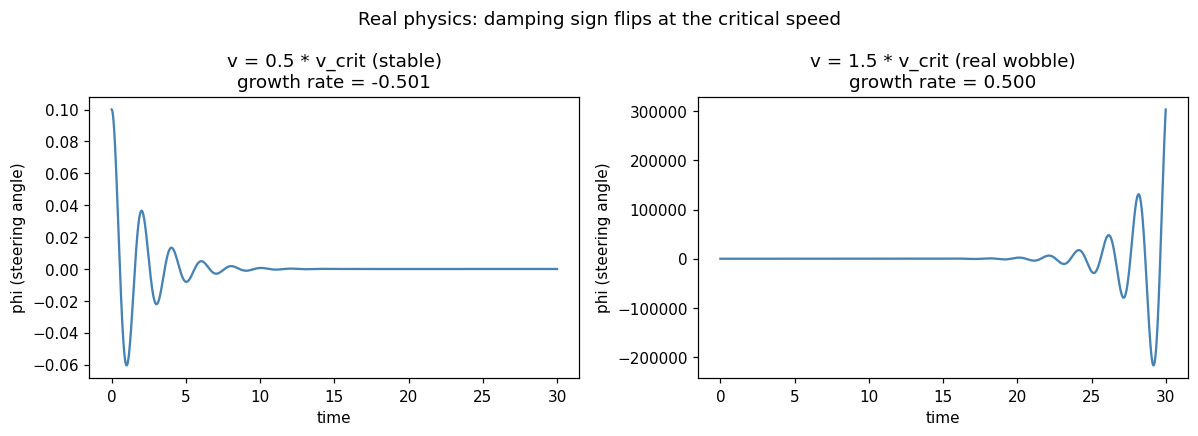

In [2]:
m, b0, b1, k = 1.0, 2.0, 0.5, 10.0
v_crit = sw.critical_speed(b0, b1)
print(f"critical speed v_crit = {v_crit}")

t = np.linspace(0, 30, 3000)   # fine time step -- RK4 is accurate here

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for v_frac, ax, label in [(0.5, axes[0], "v = 0.5 * v_crit (stable)"),
                           (1.5, axes[1], "v = 1.5 * v_crit (real wobble)")]:
    traj = sw.simulate_wobble(v_frac * v_crit, m, b0, b1, k, 0.1, 0.0, t, method="rk4")
    rate = sw.envelope_growth_rate(traj[:, 0], t)
    ax.plot(t, traj[:, 0], color="steelblue")
    ax.set_title(f"{label}\ngrowth rate = {rate:.3f}")
    ax.set_xlabel("time"); ax.set_ylabel("phi (steering angle)")
fig.suptitle("Real physics: damping sign flips at the critical speed")
fig.tight_layout()
plt.show()


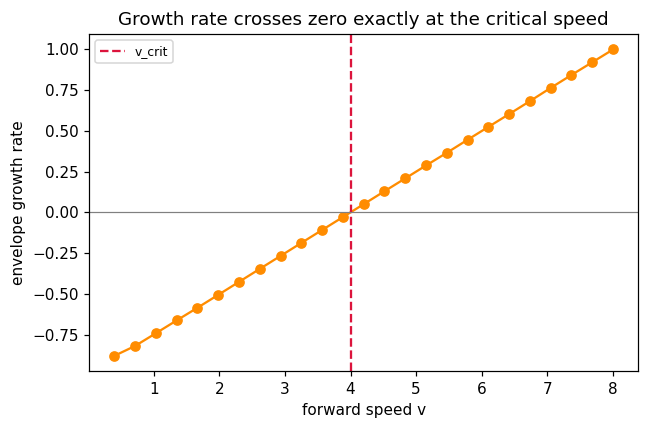

In [3]:
# growth rate vs speed, crossing zero exactly at v_crit
v_fractions = np.linspace(0.1, 2.0, 25)
rates = []
for vf in v_fractions:
    traj = sw.simulate_wobble(vf * v_crit, m, b0, b1, k, 0.1, 0.0, t, method="rk4")
    rates.append(sw.envelope_growth_rate(traj[:, 0], t))

plt.figure(figsize=(6, 4))
plt.plot(v_fractions * v_crit, rates, "o-", color="darkorange")
plt.axvline(v_crit, ls="--", color="crimson", label="v_crit")
plt.axhline(0, color="gray", lw=0.8)
plt.xlabel("forward speed v"); plt.ylabel("envelope growth rate")
plt.title("Growth rate crosses zero exactly at the critical speed")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2. The fake instability: a numerical-integrator artifact

Now fix the speed at a PHYSICALLY stable value ($v=0.5\,v_{crit}$, damping
positive, true decay) and integrate with a much coarser time step using two
different methods: explicit Euler (cheap, low stability margin) and RK4
(same cost order, far better stability margin).


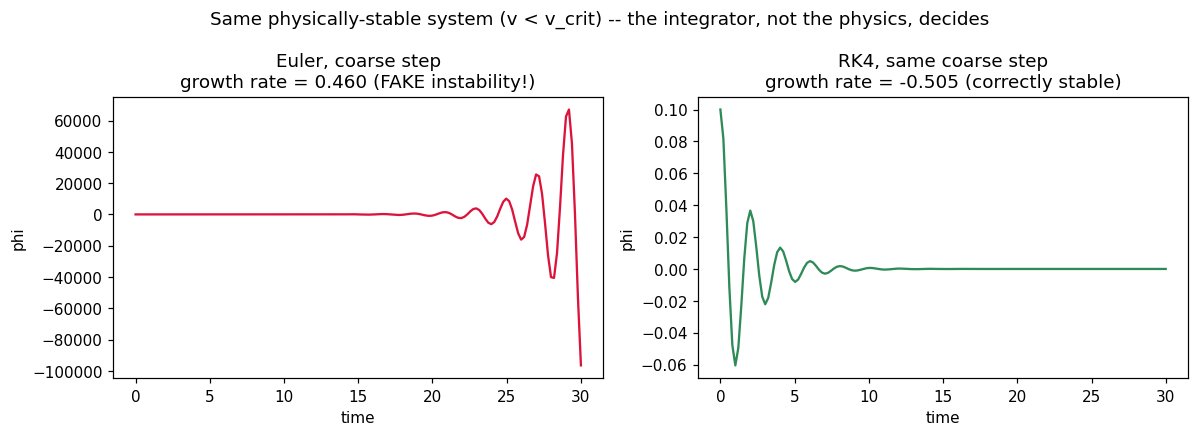

Euler growth rate at coarse step: 0.4603  (positive = numerical artifact)
RK4 growth rate at coarse step:   -0.5045  (negative = correctly stable)


In [4]:
t_coarse = np.linspace(0, 30, 150)   # same total time, far fewer steps

traj_euler = sw.simulate_wobble(0.5 * v_crit, m, b0, b1, k, 0.1, 0.0, t_coarse, method="euler")
traj_rk4 = sw.simulate_wobble(0.5 * v_crit, m, b0, b1, k, 0.1, 0.0, t_coarse, method="rk4")

rate_euler = sw.envelope_growth_rate(traj_euler[:, 0], t_coarse)
rate_rk4 = sw.envelope_growth_rate(traj_rk4[:, 0], t_coarse)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_coarse, traj_euler[:, 0], color="crimson")
axes[0].set_title(f"Euler, coarse step\ngrowth rate = {rate_euler:.3f} (FAKE instability!)")
axes[1].plot(t_coarse, traj_rk4[:, 0], color="seagreen")
axes[1].set_title(f"RK4, same coarse step\ngrowth rate = {rate_rk4:.3f} (correctly stable)")
for ax in axes:
    ax.set_xlabel("time"); ax.set_ylabel("phi")
fig.suptitle("Same physically-stable system (v < v_crit) -- the integrator, not the physics, decides")
fig.tight_layout()
plt.show()

print(f"Euler growth rate at coarse step: {rate_euler:.4f}  (positive = numerical artifact)")
print(f"RK4 growth rate at coarse step:   {rate_rk4:.4f}  (negative = correctly stable)")


## Summary

Two completely different mechanisms can make $\phi(t)$ grow: a real
physical instability (forward speed exceeding $v_{crit}$, where damping
goes negative) and a purely numerical one (an integrator's stability
margin exceeded by too large a time step). Both were shown directly from
the same `wobble_rhs` equation -- the growth-rate-vs-speed sweep confirms
the real transition happens exactly at $v_{crit}$, and the Euler-vs-RK4
comparison at a fixed, physically stable speed shows a numerical artifact
that looks identical to real wobble unless you check it against a better
integrator. The same caution applies to any rigid-body physics engine
(MuJoCo included): an unstable integrator can manufacture instabilities
that aren't physically there.
